# Generación de Espectros de Transmisión con POSEIDON
En este notebook calcularemos y compararemos los espectros de transmisión de la Tierra y TRAPPIST-1e para distintos escenarios de agricultura.

In [8]:
from POSEIDON.core import create_star, create_planet
from POSEIDON.constants import R_Sun, R_E, M_E

#***** Define stellar properties *****#

R_s = 0.11697*R_Sun   # Stellar radius (m)
T_s = 2559.0          # Stellar effective temperature (K)
Met_s = 0.04          # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 5.21        # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s,
                   stellar_grid= 'phoenix')

#***** Define planet properties *****#

planet_name = 'TRAPPIST-1e'  # Planet name used for plots, output files etc.

R_p = 0.917985*R_E     # Planetary radius (m)
M_p = 0.6356*M_E       # Planetary mass (kg)
T_eq = 255.0           # Equilibrium temperature (K)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq)

In [9]:
from POSEIDON.core import define_model
import numpy as np

#***** Define models *****#

model_name_1 = 'Trappist_A0_PreAgri'   # First model
model_name_2 = 'Trappist_A1_Current'  # Second model
model_name_3 = 'Trappist_A2_Moderate' # Third model
model_name_4 = 'Trappist_A3_Extreme'  # Fourth model
model_name_0 = 'Sun_A0_PreAgri' 

bulk_species = ['N2']                                      # For terrestrial planets, only the single most abundant gas should be provided here
param_species = ['H2O', 'CO2', 'CH4', 'O2', 'O3', 'N2O', 'NH3']

# Create the model objects
model_1 = define_model(model_name_1, bulk_species, param_species,
                       PT_profile = 'file_read', X_profile = 'file_read',
                       radius_unit = 'R_E', surface = True)
model_2 = define_model(model_name_2, bulk_species, param_species,
                       PT_profile = 'file_read', X_profile = 'file_read',
                       radius_unit = 'R_E', surface = True)
model_3 = define_model(model_name_3, bulk_species, param_species,
                       PT_profile = 'file_read', X_profile = 'file_read',
                       radius_unit = 'R_E', surface = True)
model_4 = define_model(model_name_4, bulk_species, param_species,
                       PT_profile = 'file_read', X_profile = 'file_read',
                       radius_unit = 'R_E', surface = True)

model_0 = define_model(model_name_0,  bulk_species, param_species,
                       PT_profile = 'file_read', X_profile = 'file_read',
                       radius_unit = 'R_E', surface = True)

#***** Create model pressure grid (same for both models) *****#

# Specify the pressure grid of the atmosphere
P_min = 1.0e-10    # 0.1 ubar
P_max = 10.0      # 10 bar (you can extend the atmosphere deeper than the surface)
N_layers = 100    # 100 layers

P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

# Add the surface pressure
P_surf = 1.0      # Effectively acts as a cloud deck opaque at all wavelengths

# Specify the reference pressure and radius
P_ref = P_surf    # We'll set the reference pressure at the surface
R_p_ref = R_p     # Radius at reference pressure

In [10]:
from POSEIDON.utility import read_PT_file

# Specify location of the P-T profile file
PT_file_dir = '../profiles/'  # Directory containing the P-T profile files
PT_file_name_1 = 'Trappist_A0_PreAgri_PT.txt'
PT_file_name_2 = 'Trappist_A1_Current_PT.txt'
PT_file_name_3 = 'Trappist_A2_Moderate_PT.txt'
PT_file_name_4 = 'Trappist_A3_Extreme_PT.txt'

# Read the P-T profile files
T_Modern = read_PT_file(PT_file_dir, PT_file_name_1, P, skiprows = 1,
                        P_column = 2, T_column = 3)
T_Archean = read_PT_file(PT_file_dir, PT_file_name_2, P, skiprows = 1,
                        P_column = 2, T_column = 3)
T_Moderate = read_PT_file(PT_file_dir, PT_file_name_3, P, skiprows = 1,
                        P_column = 2, T_column = 3)
T_Extreme = read_PT_file(PT_file_dir, PT_file_name_4, P, skiprows = 1,
                        P_column = 2, T_column = 3)
T_PreAgri_ref = read_PT_file(PT_file_dir, PT_file_name_4, P, skiprows = 1,
                        P_column = 2, T_column = 3)

In [11]:
from POSEIDON.utility import read_chem_file

# Specify location of the composition file
chem_file_dir = '../profiles/'  # Directory containing the composition files
chem_file_name_1 = 'Trappist_A0_PreAgri_chem.txt'
chem_file_name_2 = 'Trappist_A1_Current_chem.txt'
chem_file_name_3 = 'Trappist_A2_Moderate_chem.txt'
chem_file_name_4 = 'Trappist_A3_Extreme_chem.txt'
chem_file_name_0 = 'Earth_A0_PreAgri_chem.txt'


chem_species_file = [
    'OH', 'H2', 'H2O', 'H', 'O', 'CH', 'C', 'CH2', 'CH3', 'CH4',
    'C2', 'C2H2', 'C2H', 'C2H3', 'C2H4', 'C2H5', 'C2H6',
    'CO', 'CO2', 'CH2OH', 'H2CO', 'HCO', 'CH3O', 'CH3OH', 'CH3CO',
    'O2', 'H2CCO', 'HCCO', 'CH3O2', 'HO2', 'CH3OOH',
    'N', 'NH', 'CN', 'HCN', 'NH2', 'N2', 'NH3', 'NO',
    'N2H2', 'N2H', 'N2H3', 'N2H4', 'HNO', 'H2CN', 'HNCO', 'NO2', 'N2O',
    'C4H2', 'CH2NH2', 'CH2NH', 'CH3NH2', 'CH3CHO',
    'O3', 'NO3', 'HNO3', 'HNO2', 'NCO', 'N2O5',
    'S', 'SH', 'S2', 'SO', 'H2S', 'CS', 'COS', 'CS2', 'NS', 'HS2', 'SO2',
    'S4', 'S8', 'HCS', 'S3', 'H2O2', 'SO3', 'HSO3', 'HSO', 'H2SO4',
    'HC3N', 'CH3CN', 'CH2CN', 'C2H3CN', 'CH3SH', 'CH3S',
    'C3H3', 'C3H2', 'C3H4', 'C6H5', 'C6H6', 'C4H3', 'C4H5',
    'S2O', 'O_1', 'CH2_1', 'N_2D', 'He', 'H2O_l_s', 'H2SO4_l'
]
# Read the composition files
X_A0 = read_chem_file(chem_file_dir, chem_file_name_1, P, chem_species_file,
                          chem_species_in_model = model_1['chemical_species'],
                          skiprows = 1)
X_A1 = read_chem_file(chem_file_dir, chem_file_name_2, P, chem_species_file,
                           chem_species_in_model = model_2['chemical_species'],
                           skiprows = 1)
X_A2 = read_chem_file(chem_file_dir, chem_file_name_3, P, chem_species_file,
                           chem_species_in_model = model_3['chemical_species'],
                           skiprows = 1)
X_A3 = read_chem_file(chem_file_dir, chem_file_name_4, P, chem_species_file,
                           chem_species_in_model = model_4['chemical_species'],
                           skiprows = 1) 
X_Sun_A0 = read_chem_file(chem_file_dir, chem_file_name_0, P, chem_species_file,
                           chem_species_in_model = model_0['chemical_species'],
                           skiprows = 1) 


In [12]:
X_A0.shape

(8, 100)

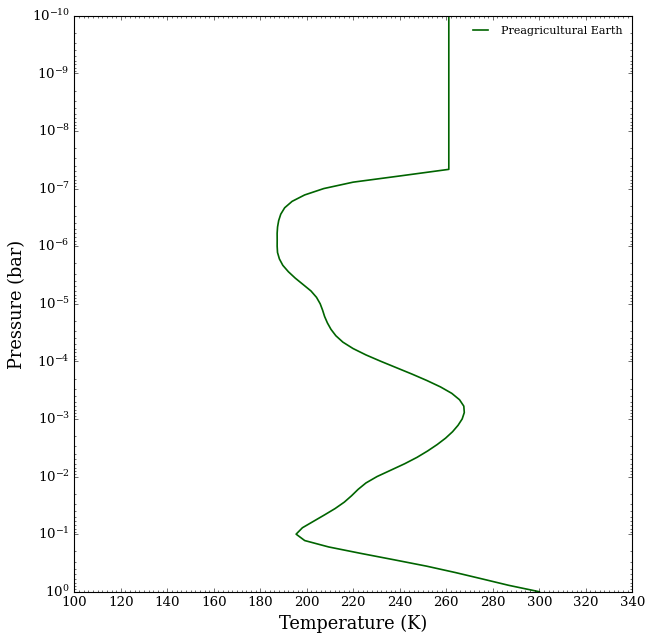

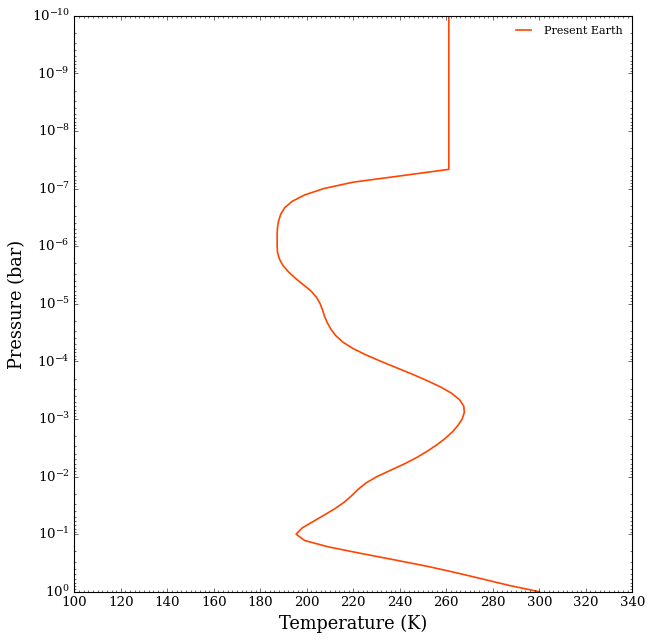

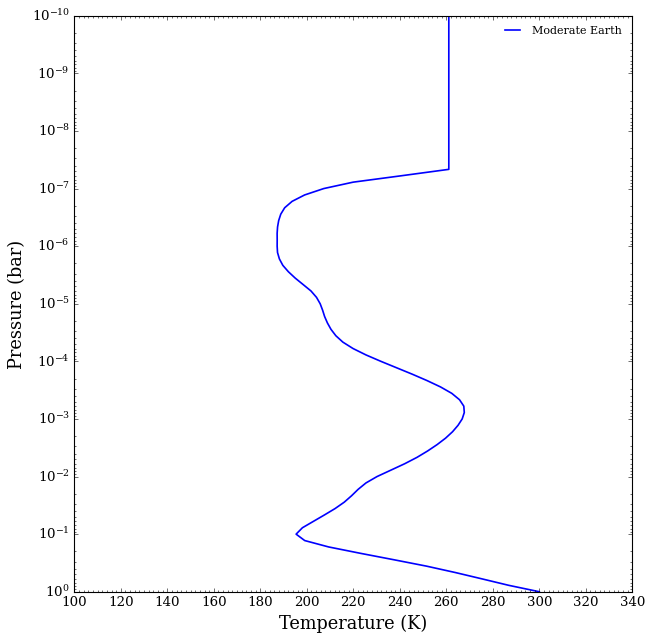

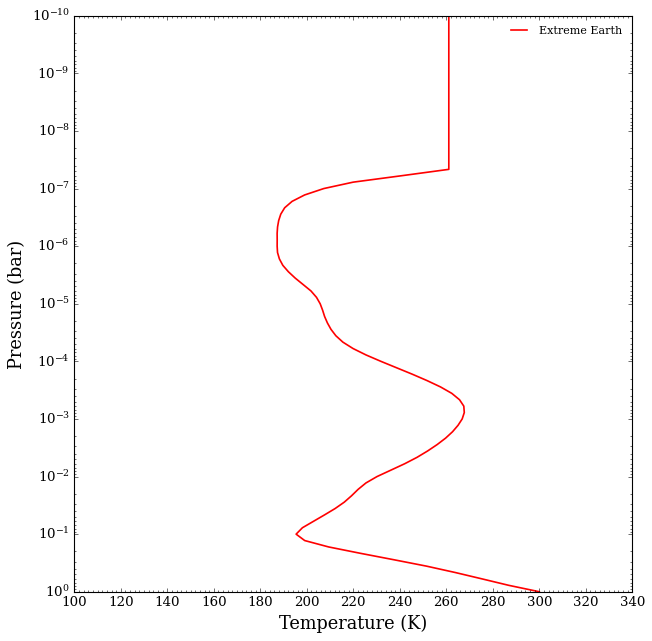

In [13]:
from POSEIDON.core import make_atmosphere
from POSEIDON.visuals import plot_geometry, plot_PT, plot_chem

# Generate the atmospheres
atmosphere_A0 = make_atmosphere(planet, model_1, P, P_ref, R_p_ref,
                               T_input = T_Modern, X_input = X_A0,    # Provide T and X directly here
                               P_surf = P_surf)                           # Also provide the surface pressure
atmosphere_A1 = make_atmosphere(planet, model_2, P, P_ref, R_p_ref,
                               T_input = T_Archean, X_input = X_A1,    # Provide T and X directly here
                               P_surf = P_surf)                             # Also provide the surface pressure
atmosphere_A2 = make_atmosphere(planet, model_3, P, P_ref, R_p_ref,
                               T_input = T_Moderate, X_input = X_A2,    # Provide T and X directly here
                               P_surf = P_surf)                             # Also provide the surface pressure
atmosphere_A3 = make_atmosphere(planet, model_4, P, P_ref, R_p_ref,
                               T_input = T_Extreme, X_input = X_A3,    # Provide T and X directly here
                               P_surf = P_surf)                             # Also provide the surface pressure

atmosphere_Earth_A0 = make_atmosphere(planet, model_0, P, P_ref, R_p_ref,
                               T_input = T_Extreme, X_input = X_Sun_A0,    # Provide T and X directly here
                               P_surf = P_surf)   


#***** Produce plots of atmospheric properties *****#

# Compare the P-T profiles first
fig_PT_1 = plot_PT(planet, model_1, atmosphere_A0, T_min = 100, T_max = 340,       # This demonstrates several plot customisation options
                   log_P_max = np.log10(P_surf), PT_label = 'Preagricultural Earth',
                   legend_location = 'upper right', colour = 'darkgreen')
fig_PT_2 = plot_PT(planet, model_2, atmosphere_A1, T_min = 100, T_max = 340,
                   log_P_max = np.log10(P_surf), PT_label = 'Present Earth',
                   legend_location = 'upper right', colour = 'orangered')
fig_PT_3 = plot_PT(planet, model_3, atmosphere_A2, T_min = 100, T_max = 340,
                   log_P_max = np.log10(P_surf), PT_label = 'Moderate Earth',
                   legend_location = 'upper right', colour = 'blue')
fig_PT_4 = plot_PT(planet, model_4, atmosphere_A3, T_min = 100, T_max = 340,
                   log_P_max = np.log10(P_surf), PT_label = 'Extreme Earth',
                   legend_location = 'upper right', colour = 'red')
#fig_geom_1 = plot_geometry(planet, star, model_1, atmosphere_1)   # This figure looks a little boring for a (tiny) Earth-like atmosphere!

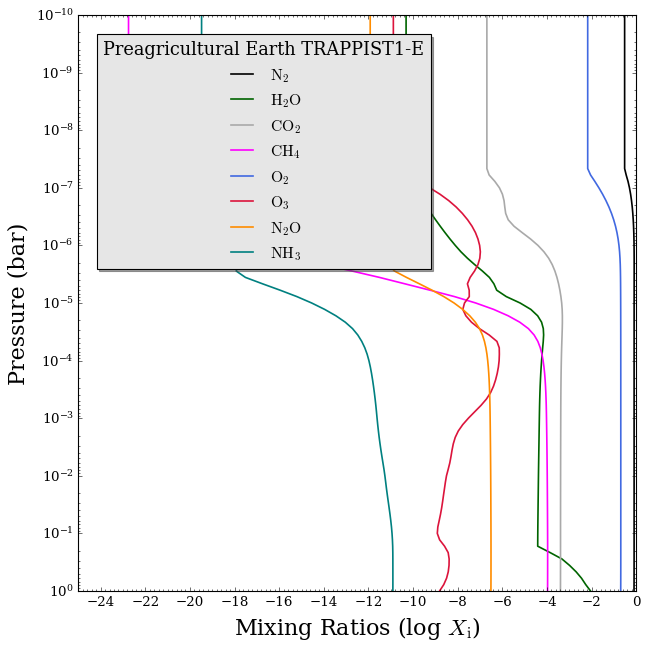

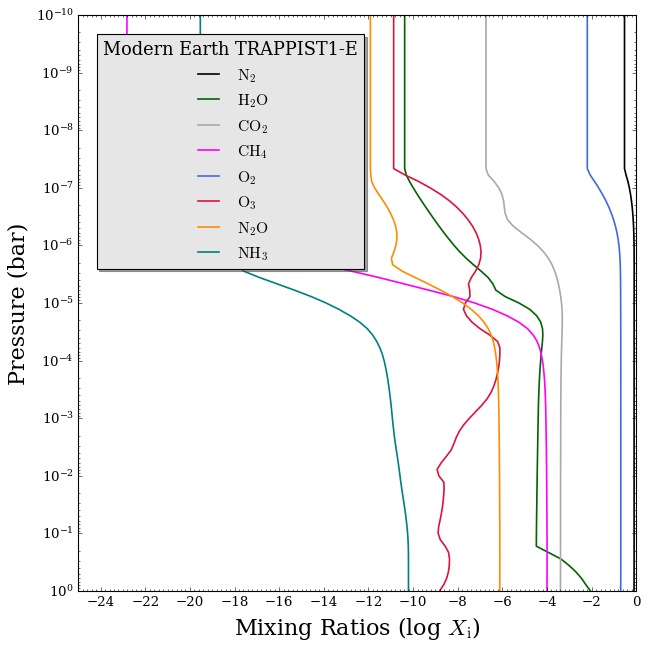

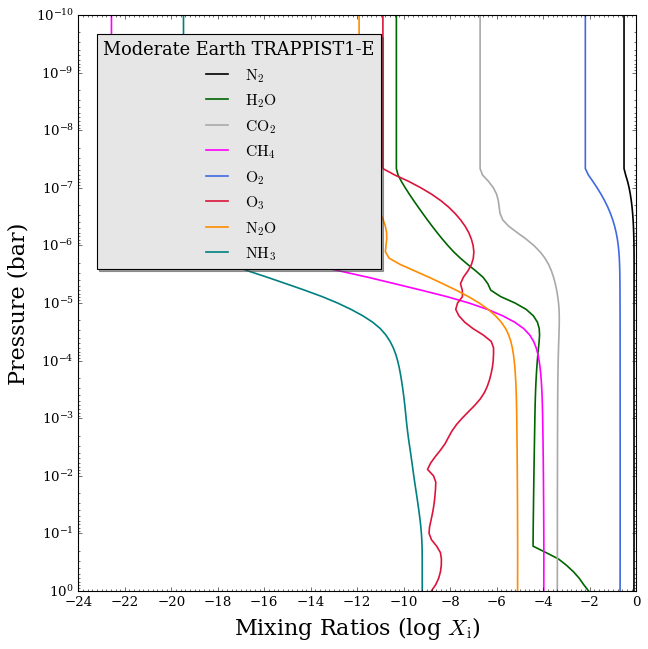

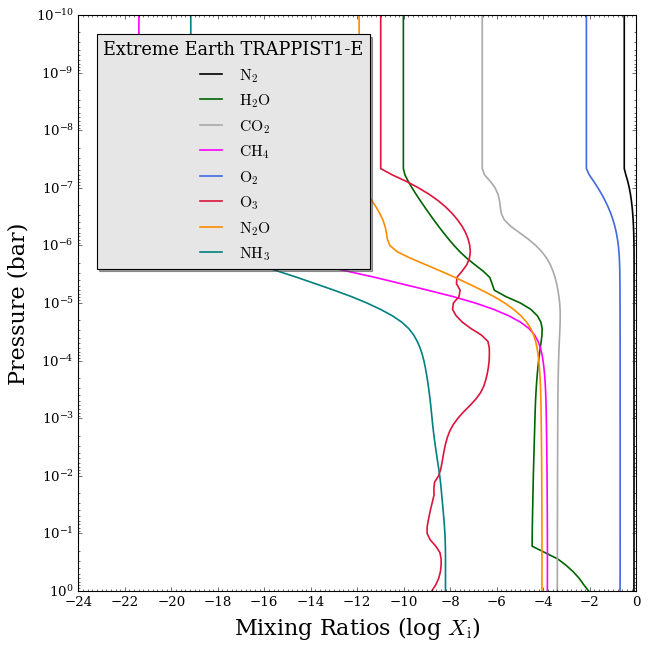

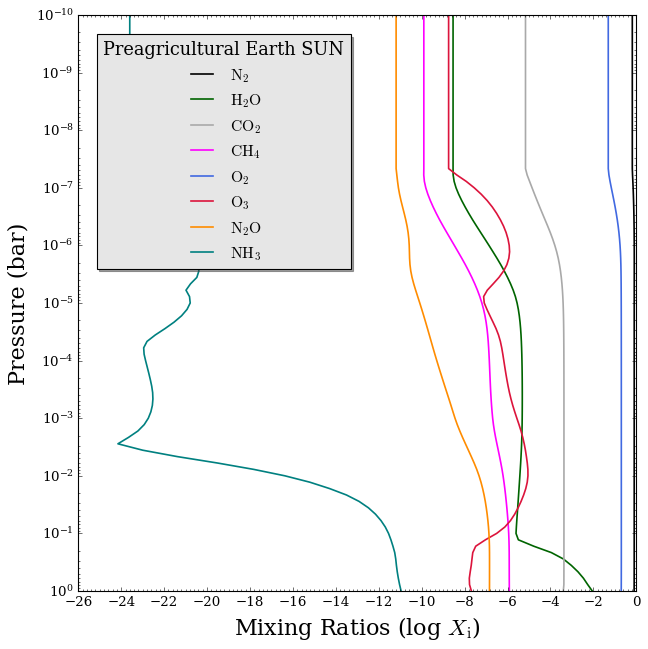

In [14]:
# Compare the mixing ratio profiles
fig_chem_1 = plot_chem(planet, model_1, atmosphere_A0, log_P_max = np.log10(P_surf),
                       legend_title = 'Preagricultural Earth TRAPPIST1-E', legend_location = 'upper left',
                       colour_list = ['black', 'darkgreen', 'darkgrey', 'magenta',
                                      'royalblue', 'crimson', 'darkorange', 'teal'])
fig_chem_2 = plot_chem(planet, model_2, atmosphere_A1, log_P_max = np.log10(P_surf),
                       legend_title = 'Modern Earth TRAPPIST1-E', legend_location = 'upper left',
                       colour_list = ['black', 'darkgreen', 'darkgrey', 'magenta',
                                      'royalblue', 'crimson', 'darkorange', 'teal'])
fig_chem_3 = plot_chem(planet, model_3, atmosphere_A2, log_P_max = np.log10(P_surf),
                       legend_title = 'Moderate Earth TRAPPIST1-E', legend_location = 'upper left',
                       colour_list = ['black', 'darkgreen', 'darkgrey', 'magenta',
                                      'royalblue', 'crimson', 'darkorange', 'teal'])
fig_chem_4 = plot_chem(planet, model_4, atmosphere_A3, log_P_max = np.log10(P_surf),
                       legend_title = 'Extreme Earth TRAPPIST1-E', legend_location = 'upper left',
                       colour_list = ['black', 'darkgreen', 'darkgrey', 'magenta',
                                       'royalblue', 'crimson', 'darkorange', 'teal'])

fig_chem_0 = plot_chem(planet, model_0, atmosphere_Earth_A0, log_P_max = np.log10(P_surf),
                       legend_title = 'Preagricultural Earth SUN', legend_location = 'upper left',
                       colour_list = ['black', 'darkgreen', 'darkgrey', 'magenta',
                                      'royalblue', 'crimson', 'darkorange', 'teal'])


In [15]:
atmosphere_A0.keys()

dict_keys(['P', 'T', 'g', 'n', 'r', 'r_up', 'r_low', 'dr', 'P_surf', 'X', 'X_active', 'X_CIA', 'X_ff', 'X_bf', 'mu', 'N_sectors', 'N_zones', 'alpha', 'beta', 'phi', 'theta', 'phi_edge', 'theta_edge', 'dphi', 'dtheta', 'kappa_cloud_0', 'P_cloud', 'f_cloud', 'phi_cloud_0', 'theta_cloud_0', 'a', 'gamma', 'is_physical', 'mu_back', 'H', 'r_m', 'log_n_max', 'fractional_scale_height', 'aerosol_species', 'r_i_real', 'r_i_complex', 'log_X_Mie', 'P_cloud_bottom', 'kappa_cloud_eddysed', 'g_cloud_eddysed', 'w_cloud_eddysed', 'log_r_m_std_dev', 'f_both', 'f_aerosol_1', 'f_aerosol_2', 'f_clear'])

In [16]:
from POSEIDON.core import read_opacities, wl_grid_constant_R

#***** Wavelength grid *****#

wl_min = 0.5      # Minimum wavelength (um) - Ampliado a 0.5 para que cubra a NIRSpec completo
wl_max = 14.0     # Maximum wavelength (um)
R = 10000         # Spectral resolution of grid

wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# Define fine temperature grid (K)
T_fine_min = 100     # 100 K lower limit covers the TRAPPIST-1e P-T profile
T_fine_max = 400     # 300 K upper limit covers the TRAPPIST-1e P-T profile
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -10.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 0.0    # 1 bar is the surface pressure, so no need to go deeper
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step),
                       log_P_fine_step)

# Create opacity object (both models share the same molecules, so we only need one)
opac = read_opacities(model_1, wl, opacity_treatment, T_fine, log_P_fine,
                      opacity_database = 'High-T')

Reading in cross sections in opacity sampling mode...
CO2-CO2 done
CO2-CH4 done
N2-N2 done
N2-H2O done
O2-O2 done
O2-CO2 done
O2-N2 done
H2O done
CO2 done
CH4 done
O2 done
O3 done
N2O done
NH3 done
Opacity pre-interpolation complete.


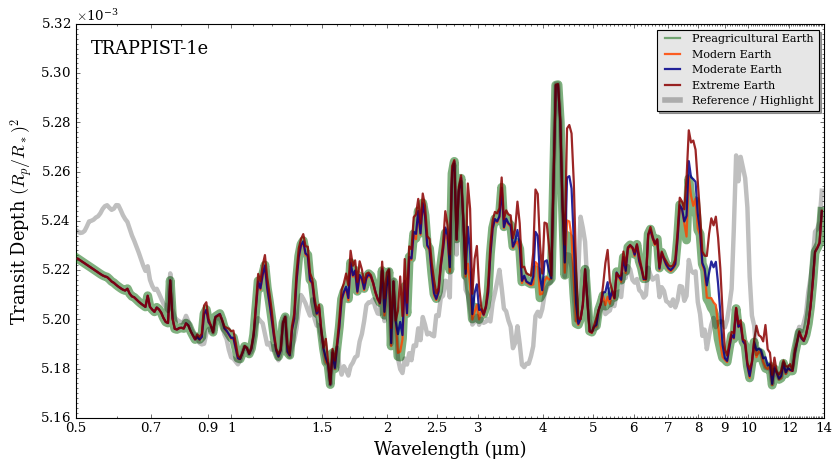

In [17]:
from POSEIDON.core import compute_spectrum
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

# Generate our first transmission spectrum
spectrum_A0 = compute_spectrum(planet, star, model_1, atmosphere_A0, opac, wl,
                                   spectrum_type = 'transmission')
spectrum_A1 = compute_spectrum(planet, star, model_2, atmosphere_A1, opac, wl,
                                    spectrum_type = 'transmission')
spectrum_A2 = compute_spectrum(planet, star, model_3, atmosphere_A2, opac, wl,
                                    spectrum_type = 'transmission')
spectrum_A3 = compute_spectrum(planet, star, model_4, atmosphere_A3, opac, wl,
                                    spectrum_type = 'transmission')

spectrum_A0_SUN = compute_spectrum(planet, star, model_0, atmosphere_Earth_A0, opac, wl,
                                    spectrum_type = 'transmission')



spectra = []   # Empty plot collection

# Add the two model spectra to the plot collection object
spectra = plot_collection(spectrum_A0, wl, collection = spectra)
spectra = plot_collection(spectrum_A1, wl, collection = spectra)
spectra = plot_collection(spectrum_A2, wl, collection = spectra)
spectra = plot_collection(spectrum_A3, wl, collection = spectra)
spectra = plot_collection(spectrum_A0_SUN, wl, collection = spectra)

fig_spec = plot_spectra(
    spectra, planet,
    R_to_bin=100,
    plot_full_res=False,
    y_min=5.16e-3, y_max=5.32e-3,
    spectra_labels=[
        'Preagricultural Earth',
        'Modern Earth',
        'Moderate Earth',
        'Extreme Earth',
        'Reference / Highlight'   # <- pon el label que quieras (o '' si no quieres leyenda)
    ],
    colour_list=['darkgreen', 'orangered', 'darkblue', 'darkred', 'black'],
    figure_shape='wide',
    line_width_list=[8, 2, 2, 2, 4],                 # <- último grueso
    line_alpha_list=[0.5, 0.85, 0.85, 0.85, 0.25],  # <- último transparentoso
    # opcional: para que en la leyenda se vea también “grueso”
    legend_line_size=[2, 2, 2, 2, 5],
)

In [18]:
from POSEIDON.contributions import spectral_contribution

spectrum_A0, spectrum_contribution_list_names_A0, \
spectrum_contribution_list_A0 = spectral_contribution(planet, star, model_1,
                                                   atmosphere_A0, opac, wl,
                                                   contribution_species_list = ['N2O', 'NH3', 'CH4', 'O3'], # <--- List gas species here
                                                   bulk_species = False,                 # <--- To see bulk species contribution, set this True
                                                   cloud_contribution = False,           # <--- To see cloud or aerosol contribution, set this True
                                                   )

spectrum_A3, spectrum_contribution_list_names_A3, \
spectrum_contribution_list_A3 = spectral_contribution(planet, star, model_4,
                                                   atmosphere_A3, opac, wl,
                                                   contribution_species_list = ['N2O', 'NH3', 'CH4', 'O3'], # <--- List gas species here
                                                   bulk_species = False,                 # <--- To see bulk species contribution, set this True
                                                   cloud_contribution = False,           # <--- To see cloud or aerosol contribution, set this True
                                                   )


In [19]:
spectrum_contribution_list_A0

[array([0.0052252 , 0.00522519, 0.00522519, ..., 0.00516868, 0.00516957,
        0.00516876]),
 array([0.0052252 , 0.00522519, 0.00522519, ..., 0.00516841, 0.00516841,
        0.00516841]),
 array([0.0052252 , 0.00522519, 0.00522519, ..., 0.00516841, 0.00516841,
        0.00516841]),
 array([0.00522523, 0.00522522, 0.00522522, ..., 0.00516964, 0.00516922,
        0.00516919])]

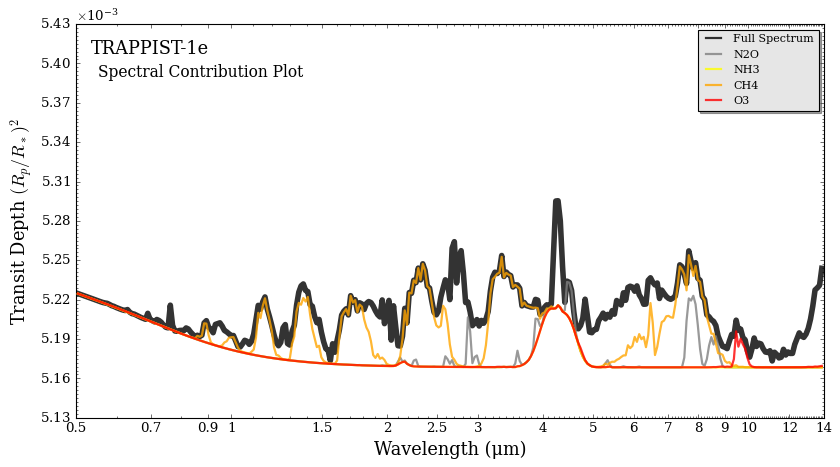

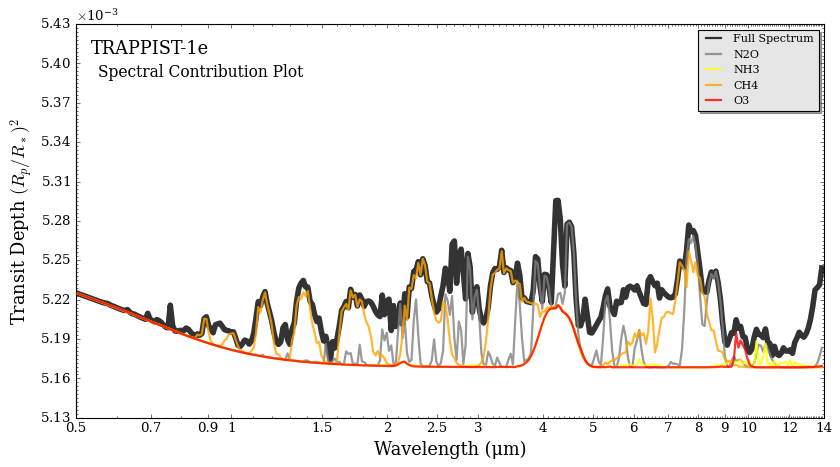

In [20]:
from POSEIDON.contributions import plot_spectral_contribution



plot_spectral_contribution(planet, wl, spectrum_A0, spectrum_contribution_list_names_A0, spectrum_contribution_list_A0,
                           line_width_list = [5,2,2,2,2],
                           colour_list = ['black', 'gray', 'yellow','orange', 'red'],
                           save_fig = True)

plot_spectral_contribution(planet, wl, spectrum_A3, spectrum_contribution_list_names_A3, spectrum_contribution_list_A3,
                           line_width_list = [5,2,2,2,2],
                           colour_list = ['black', 'gray', 'yellow','orange', 'red'],
                           save_fig = True)

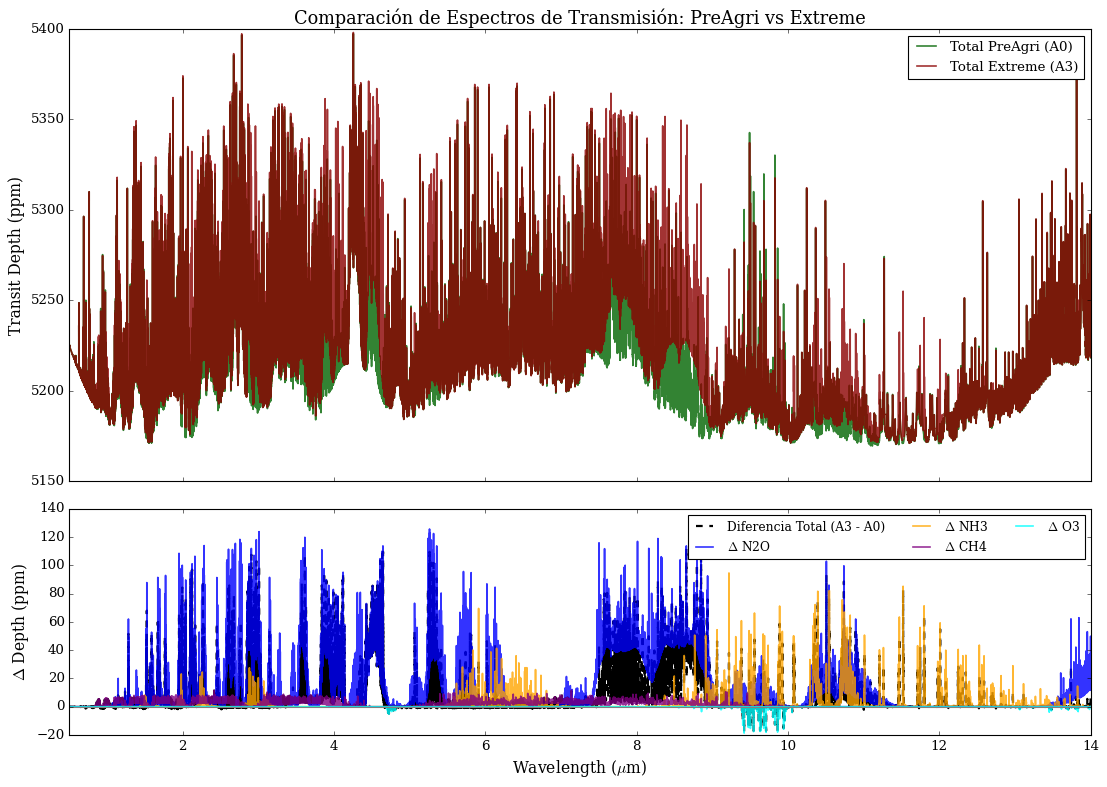

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Factor de conversión a partes por millón (ppm) para que sea más legible
ppm = 1e6

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# --- Panel Superior: Espectros Totales ---
ax1.plot(wl, spectrum_A0 * ppm, label='Total PreAgri (A0)', color='darkgreen', lw=1.5, alpha=0.8)
ax1.plot(wl, spectrum_A3 * ppm, label='Total Extreme (A3)', color='darkred', lw=1.5, alpha=0.8)

ax1.set_ylabel('Transit Depth (ppm)', fontsize=14)
ax1.legend(loc='upper right', fontsize=12)
ax1.set_title('Comparación de Espectros de Transmisión: PreAgri vs Extreme', fontsize=16)
ax1.tick_params(axis='both', labelsize=12)

# --- Panel Inferior: Diferencias (A3 - A0) ---
colors = ['blue', 'orange', 'purple', 'cyan', 'magenta', 'brown']

# Diferencia total
total_diff = (spectrum_A3 - spectrum_A0) * ppm
ax2.plot(wl, total_diff, label='Diferencia Total (A3 - A0)', color='black', lw=2, linestyle='--')

# Diferencias por molécula
for i, name in enumerate(spectrum_contribution_list_names_A0):
    if name in spectrum_contribution_list_names_A3:
        idx_A3 = spectrum_contribution_list_names_A3.index(name)
        # Calculamos la diferencia para esta molécula en específico
        diff = (spectrum_contribution_list_A3[idx_A3] - spectrum_contribution_list_A0[i]) * ppm
        ax2.plot(wl, diff, label=f'$\Delta$ {name}', color=colors[i % len(colors)], lw=1.5, alpha=0.8)

ax2.set_xlabel('Wavelength ($\mu$m)', fontsize=14)
ax2.set_ylabel('$\Delta$ Depth (ppm)', fontsize=14)
ax2.legend(loc='upper right', ncol=3, fontsize=11)
ax2.axhline(0, color='gray', linestyle='-', lw=1) # Línea en cero como referencia
ax2.tick_params(axis='both', labelsize=12)

# Ajustar los límites del eje X para que coincidan con los datos
ax1.set_xlim(wl[0], wl[-1])

plt.tight_layout()
plt.show()

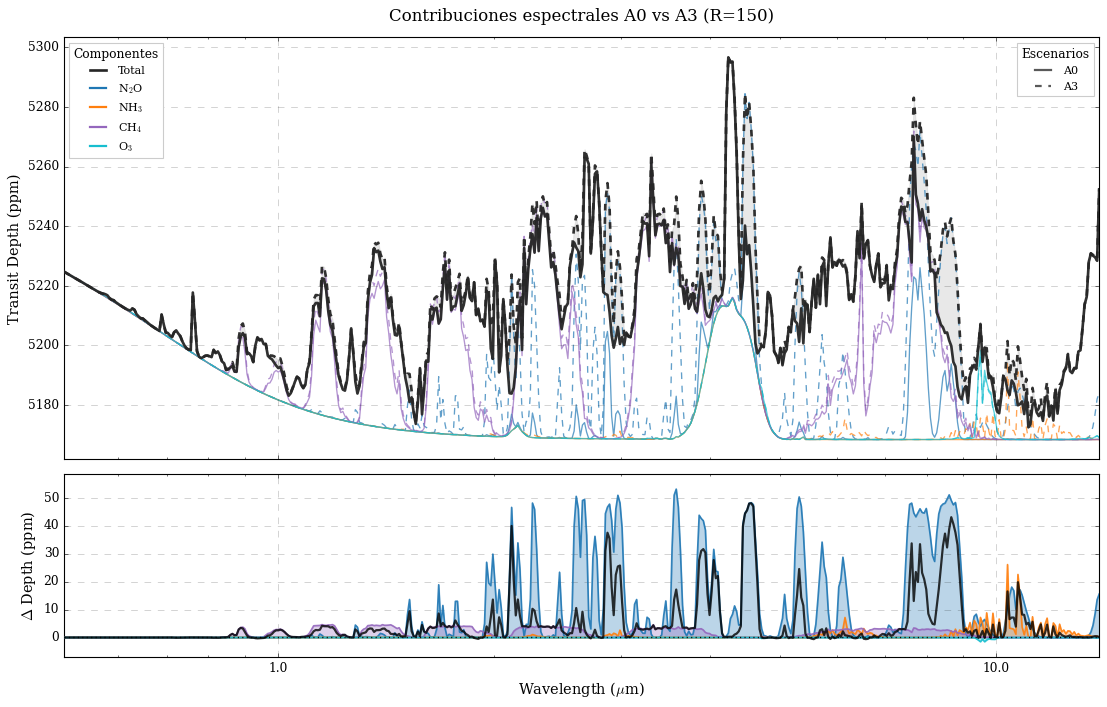

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter
from POSEIDON.utility import bin_spectrum

ppm = 1e6
R_plot = 150  # Resolución suavizada

def rebin_poseidon(wl_native, spectrum_native, R_bin):
    wl_bin, spec_bin, _ = bin_spectrum(wl_native, spectrum_native, R_bin)
    return wl_bin, spec_bin

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={'height_ratios': [2.3, 1]}
)

mol_colors = {
    'Total': '0.15',
    'N2O': '#1f77b4',
    'NH3': '#ff7f0e',
    'CH4': '#9467bd',
    'O3': '#17becf',
}

# --- Totales ---
wl_binned, spec_A0_total_bin = rebin_poseidon(wl, spectrum_A0 * ppm, R_plot)
_, spec_A3_total_bin = rebin_poseidon(wl, spectrum_A3 * ppm, R_plot)
diff_total_bin = spec_A3_total_bin - spec_A0_total_bin

# Sombreado del total entre escenarios en el panel superior (mantenido, es buena idea)
ax1.fill_between(
    wl_binned,
    spec_A0_total_bin,
    spec_A3_total_bin,
    color='0.75',
    alpha=0.35,
    zorder=1
)

# --- Contribuciones moleculares ---
all_top = [spec_A0_total_bin, spec_A3_total_bin]
all_bottom = [diff_total_bin]

for i, name in enumerate(spectrum_contribution_list_names_A0):
    if name not in spectrum_contribution_list_names_A3:
        continue

    idx_A3 = spectrum_contribution_list_names_A3.index(name)

    spec_A0_mol = spectrum_contribution_list_A0[i] * ppm
    spec_A3_mol = spectrum_contribution_list_A3[idx_A3] * ppm

    _, spec_A0_bin = rebin_poseidon(wl, spec_A0_mol, R_plot)
    _, spec_A3_bin = rebin_poseidon(wl, spec_A3_mol, R_plot)

    diff_bin = spec_A3_bin - spec_A0_bin
    color = mol_colors.get(name, 'gray')

    all_top.extend([spec_A0_bin, spec_A3_bin])
    all_bottom.append(diff_bin)

    # Panel superior: líneas de moléculas ligeramente más suaves para no saturar
    ax1.plot(
        wl_binned, spec_A0_bin,
        color=color, linestyle='-', lw=1.2, alpha=0.7, zorder=2
    )
    ax1.plot(
        wl_binned, spec_A3_bin,
        color=color, linestyle='--', lw=1.2, alpha=0.7, zorder=2
    )

    # Panel inferior: LA CLAVE ESTÁ AQUÍ. Línea + Sombreado por molécula.
    ax2.plot(
        wl_binned, diff_bin,
        color=color, linestyle='-', lw=1.5, alpha=0.9, zorder=3
    )
    ax2.fill_between(
        wl_binned, 0.0, diff_bin,
        color=color, alpha=0.3, zorder=2  # Relleno de color identificativo
    )

# Totales encima (Panel superior)
ax1.plot(
    wl_binned, spec_A0_total_bin,
    color=mol_colors['Total'], linestyle='-', lw=2.4, alpha=0.95, zorder=4
)
ax1.plot(
    wl_binned, spec_A3_total_bin,
    color=mol_colors['Total'], linestyle='--', lw=2.4, alpha=0.95, zorder=4
)

# Δ total destacado (Panel inferior)
ax2.plot(
    wl_binned, diff_total_bin,
    color='black', linestyle='-', lw=2.0, alpha=0.8, zorder=5
)

# Línea cero como referencia fuerte
ax2.axhline(0.0, color='black', lw=1.2, linestyle=':', zorder=6)

# Leyendas
legend_molecules = [
    Line2D([0], [0], color=mol_colors['Total'], lw=2.4, label='Total'),
    Line2D([0], [0], color=mol_colors['N2O'], lw=2.0, label='N$_2$O'),
    Line2D([0], [0], color=mol_colors['NH3'], lw=2.0, label='NH$_3$'),
    Line2D([0], [0], color=mol_colors['CH4'], lw=2.0, label='CH$_4$'),
    Line2D([0], [0], color=mol_colors['O3'], lw=2.0, label='O$_3$'),
]

legend_styles = [
    Line2D([0], [0], color='0.35', lw=2.0, linestyle='-', label='A0'),
    Line2D([0], [0], color='0.35', lw=2.0, linestyle='--', label='A3'),
]

leg1 = ax1.legend(
    handles=legend_molecules,
    loc='upper left',
    title='Componentes',
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    edgecolor='0.8'
)
ax1.add_artist(leg1)

ax1.legend(
    handles=legend_styles,
    loc='upper right',
    title='Escenarios',
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    edgecolor='0.8'
)

# Límites automáticos con margen
top_min = min(np.nanmin(a) for a in all_top)
top_max = max(np.nanmax(a) for a in all_top)
top_pad = 0.05 * (top_max - top_min)

bot_min = min(np.nanmin(a) for a in all_bottom)
bot_max = max(np.nanmax(a) for a in all_bottom)
bot_pad = 0.10 * (bot_max - bot_min)

ax1.set_ylim(top_min - top_pad, top_max + top_pad)
ax2.set_ylim(bot_min - bot_pad, bot_max + bot_pad)

# Formato
ax1.set_title(f'Contribuciones espectrales A0 vs A3 (R={R_plot})', fontsize=15, pad=15)
ax1.set_ylabel('Transit Depth (ppm)', fontsize=13)
ax2.set_ylabel(r'$\Delta$ Depth (ppm)', fontsize=13)
ax2.set_xlabel(r'Wavelength ($\mu$m)', fontsize=13)

ax1.set_xscale('log')
ax2.set_xscale('log')
ax1.set_xlim(wl_binned[0], wl_binned[-1])

formatter = ScalarFormatter()
formatter.set_scientific(False)
formatter.set_useOffset(False)
ax2.xaxis.set_major_formatter(formatter)

for ax in (ax1, ax2):
    ax.grid(True, which='major', alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.subplots_adjust(hspace=0.05) # Juntar un poco más los subplots
plt.show()

## Observación sintética con PandExo y flujo de trabajo en POSEIDON

En esta parte del notebook, **PandExo no se usa para recalcular el espectro atmosférico**, sino para aportar la **plantilla observacional** que luego consume **POSEIDON**. En concreto, primero se toman los archivos `.dat` generados previamente con PandExo para **NIRSpec Prism** y **MIRI LRS**, que contienen para cada bin la longitud de onda central, el semiancho del bin, la profundidad de tránsito y la incertidumbre esperada. Esos archivos se copian a un directorio común y se cargan con `load_data(...)` como `data_base`, de modo que POSEIDON conozca la malla espectral instrumental y el nivel de ruido asociado a cada observación simulada.

A partir de ahí, el flujo de trabajo es el siguiente: **(1)** se calcula con POSEIDON el espectro de transmisión teórico de cada escenario atmosférico; **(2)** `generate_syn_data_from_file(...)` proyecta ese modelo sobre la plantilla observacional derivada de PandExo, usando la misma cobertura en longitud de onda y las incertidumbres espectrales del archivo base; **(3)** al activar `Gauss_scatter=True`, se genera una realización sintética añadiendo dispersión gaussiana consistente con esos errores; **(4)** el resultado se guarda como nuevos archivos sintéticos para cada instrumento y modelo; y **(5)** esos archivos se vuelven a cargar con `load_data(...)` para compararlos visualmente con el espectro teórico mediante `plot_spectra(...)`. En otras palabras, **PandExo fija la geometría observacional y el presupuesto de ruido**, mientras que **POSEIDON aporta el modelo físico atmosférico y construye la observación sintética final**.

In [17]:
from pathlib import Path
import shutil
import numpy as np

from POSEIDON.core import load_data

# ============================================================
# Archivos base de PandExo (1 tránsito)
# ============================================================
prism_src = Path(
    "POSEIDON_output/TRAPPIST-1e/pandexo_nirspec_prism_flat/"
    "TRAPPIST-1e_flat_NIRSpec_Prism_1_transits.dat"
)

miri_src = Path(
    "POSEIDON_output/TRAPPIST-1e/pandexo_miri_lrs_flat/"
    "TRAPPIST-1e_flat_MIRI_LRS_1_transits.dat"
)

if not prism_src.exists():
    raise FileNotFoundError(f"No encontré {prism_src}")

if not miri_src.exists():
    raise FileNotFoundError(f"No encontré {miri_src}")

# ============================================================
# Carpeta común para que load_data(...) vea ambos datasets
# ============================================================
common_data_dir = Path("POSEIDON_output/TRAPPIST-1e/synthetic_data/base_1transit")
common_data_dir.mkdir(parents=True, exist_ok=True)

prism_dst = common_data_dir / prism_src.name
miri_dst = common_data_dir / miri_src.name

if prism_src.resolve() != prism_dst.resolve():
    shutil.copy2(prism_src, prism_dst)

if miri_src.resolve() != miri_dst.resolve():
    shutil.copy2(miri_src, miri_dst)

# ============================================================
# Cargar datasets base en el orden correcto
# ============================================================
datasets_base = [
    "TRAPPIST-1e_flat_NIRSpec_Prism_1_transits.dat",
    "TRAPPIST-1e_flat_MIRI_LRS_1_transits.dat",
]

instruments = [
    "JWST_NIRSpec_PRISM",
    "JWST_MIRI_LRS",
]

data_base = load_data(
    str(common_data_dir),
    datasets_base,
    instruments,
    wl,
    skiprows=1,
    wl_unit="micron",
    bin_width="half",
    spectrum_unit="(Rp/Rs)^2",
)

print("Listo: common_data_dir y data_base ya quedaron definidos.")
for d in datasets_base:
    print(" -", d)

Listo: common_data_dir y data_base ya quedaron definidos.
 - TRAPPIST-1e_flat_NIRSpec_Prism_1_transits.dat
 - TRAPPIST-1e_flat_MIRI_LRS_1_transits.dat


Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS

Datasets sintéticos cargados:
 - TRAPPIST-1e_SYNTHETIC_JWST_NIRSpec_PRISM_Trappist_A0_PreAgri_N_trans_1.dat
 - TRAPPIST-1e_SYNTHETIC_JWST_MIRI_LRS_Trappist_A0_PreAgri_N_trans_1.dat
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS

Datasets sintéticos cargados:
 - TRAPPIST-1e_SYNTHETIC_JWST_NIRSpec_PRISM_Trappist_A3_Extreme_N_trans_1.dat
 - TRAPPIST-1e_SYNTHETIC_JWST_MIRI_LRS_Trappist_A3_Extreme_N_trans_1.dat


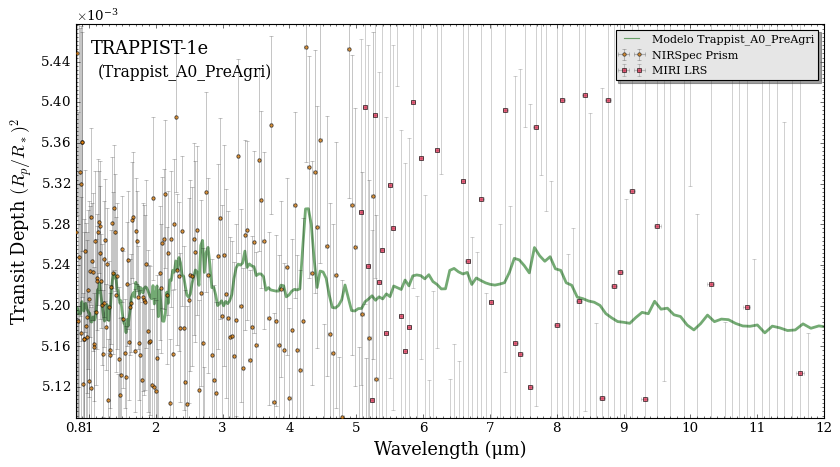

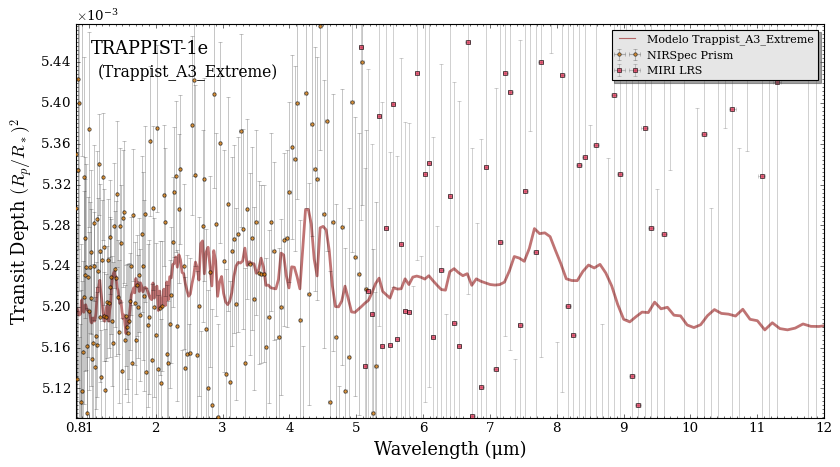

In [19]:
import numpy as np

from POSEIDON.core import load_data
from POSEIDON.instrument import generate_syn_data_from_file
from POSEIDON.utility import plot_collection
from POSEIDON.visuals import plot_spectra

# ============================================================
# Configuración común
# ============================================================
instruments = [
    "JWST_NIRSpec_PRISM",
    "JWST_MIRI_LRS",
]

# 1 tránsito en Prism y 1 tránsito en MIRI
N_trans = [1, 1]

# Binning para los datasets sintéticos
R_to_bin = [100, 100]


def make_and_plot_synthetic_model(model_label, spectrum_model, model_colour):
    """
    Genera dataset sintético Prism + MIRI para un modelo dado
    y lo plotea contra el modelo verdadero.
    """

    # --------------------------------------------------------
    # 1) Generar datos sintéticos a partir del modelo POSEIDON
    # --------------------------------------------------------
    generate_syn_data_from_file(
        planet,
        wl,
        spectrum_model,
        str(common_data_dir),
        data_base,
        R_to_bin=R_to_bin,
        N_trans=N_trans,
        label=model_label,
        Gauss_scatter=True,
    )

    # --------------------------------------------------------
    # 2) Construir nombres de archivos nuevos
    #    OJO: el orden debe coincidir con instruments
    # --------------------------------------------------------
    datasets_new = [
        f"TRAPPIST-1e_SYNTHETIC_JWST_NIRSpec_PRISM_{model_label}_N_trans_{N_trans[0]}.dat",
        f"TRAPPIST-1e_SYNTHETIC_JWST_MIRI_LRS_{model_label}_N_trans_{N_trans[1]}.dat",
    ]

    for f in datasets_new:
        full_path = common_data_dir / f
        if not full_path.exists():
            raise FileNotFoundError(f"No encontré el archivo sintético esperado: {full_path}")

    print("\nDatasets sintéticos cargados:")
    for d in datasets_new:
        print(" -", d)

    # --------------------------------------------------------
    # 3) Cargar el nuevo dataset sintético
    # --------------------------------------------------------
    data_new = load_data(
        str(common_data_dir),
        datasets_new,
        instruments,
        wl,
        skiprows=1,
        wl_unit="micron",
        bin_width="half",
        spectrum_unit="(Rp/Rs)^2",
    )

    # --------------------------------------------------------
    # 4) Crear colección del modelo
    # --------------------------------------------------------
    spectra = []
    spectra = plot_collection(spectrum_model, wl, collection=spectra)

    # --------------------------------------------------------
    # 5) Límites de eje y útiles
    # --------------------------------------------------------
    mask_plot = (wl >= 0.8) & (wl <= 12.0)
    smin = float(np.min(spectrum_model[mask_plot]))
    smax = float(np.max(spectrum_model[mask_plot]))
    span = smax - smin

    if span < 2e-5:
        span = 2e-5

    pad = 0.35 * span
    y_min = smin - pad
    y_max = smax + pad

    # --------------------------------------------------------
    # 6) Plot final
    # --------------------------------------------------------
    fig_spec = plot_spectra(
        spectra,
        planet,
        data_properties=data_new,
        R_to_bin=100,
        plot_full_res=False,
        show_data=True,
        spectra_labels=[f"Modelo {model_label}"],
        colour_list=[model_colour],
        line_alpha_list=[0.55],                 # modelo más transparente
        line_width_list=[2.5],

        data_labels=["NIRSpec Prism", "MIRI LRS"],
        data_colour_list=["darkorange", "crimson"],
        data_alpha_list=[0.65, 0.65],           # puntos más transparentes
        data_eline_alpha_list=[0.25, 0.20],     # barras mucho más suaves
        data_eline_width_list=[0.8, 0.8],

        y_min=y_min,
        y_max=y_max,
        wl_min=0.8,
        wl_max=12.0,
        figure_shape="wide",
        wl_axis="linear",
        plt_label=f"({model_label})",
    )

    return data_new, fig_spec


# ============================================================
# A0
# ============================================================
data_A0_new, fig_A0 = make_and_plot_synthetic_model(
    model_label="Trappist_A0_PreAgri",
    spectrum_model=spectrum_A0,
    model_colour="darkgreen",
)

# ============================================================
# A3
# ============================================================
data_A3_new, fig_A3 = make_and_plot_synthetic_model(
    model_label="Trappist_A3_Extreme",
    spectrum_model=spectrum_A3,
    model_colour="darkred",
)

## Más Observaciones: 10 y 100 Tránsitos

Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS

Datasets sintéticos cargados:
 - TRAPPIST-1e_SYNTHETIC_JWST_NIRSpec_PRISM_Trappist_A0_PreAgri_N_trans_10.dat
 - TRAPPIST-1e_SYNTHETIC_JWST_MIRI_LRS_Trappist_A0_PreAgri_N_trans_10.dat
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS

Datasets sintéticos cargados:
 - TRAPPIST-1e_SYNTHETIC_JWST_NIRSpec_PRISM_Trappist_A3_Extreme_N_trans_10.dat
 - TRAPPIST-1e_SYNTHETIC_JWST_MIRI_LRS_Trappist_A3_Extreme_N_trans_10.dat


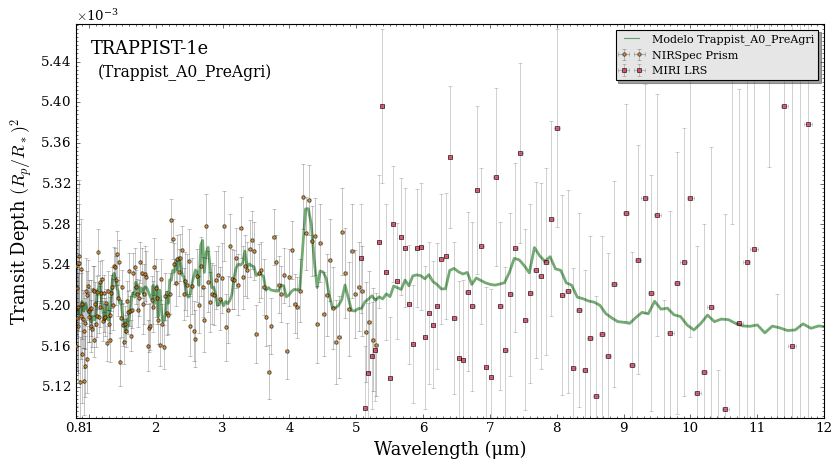

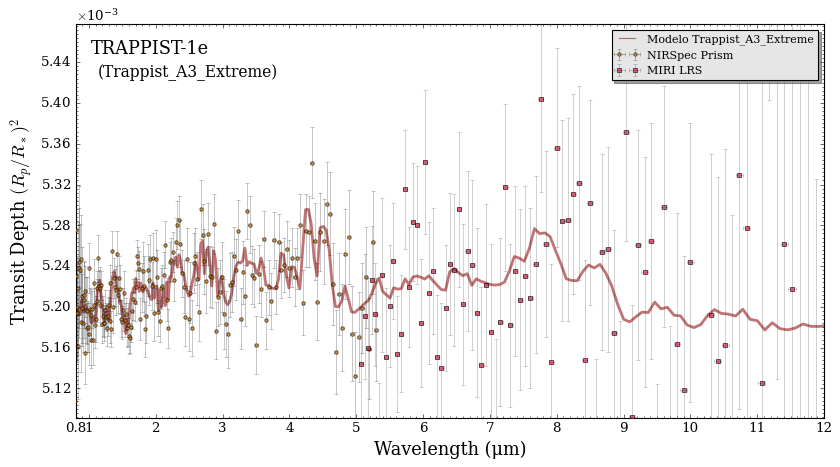

In [20]:
# ============================================================
# A0 & A3 (10 Transits)
# ============================================================
# Modificamos la variable global N_trans a 10 tránsitos
N_trans = [10, 10]

data_A0_new_10, fig_A0_10 = make_and_plot_synthetic_model(
    model_label="Trappist_A0_PreAgri",
    spectrum_model=spectrum_A0,
    model_colour="darkgreen"
)

data_A3_new_10, fig_A3_10 = make_and_plot_synthetic_model(
    model_label="Trappist_A3_Extreme",
    spectrum_model=spectrum_A3,
    model_colour="darkred"
)

Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS

Datasets sintéticos cargados:
 - TRAPPIST-1e_SYNTHETIC_JWST_NIRSpec_PRISM_Trappist_A0_PreAgri_N_trans_100.dat
 - TRAPPIST-1e_SYNTHETIC_JWST_MIRI_LRS_Trappist_A0_PreAgri_N_trans_100.dat
Creating synthetic data
JWST_NIRSpec_PRISM
JWST_MIRI_LRS

Datasets sintéticos cargados:
 - TRAPPIST-1e_SYNTHETIC_JWST_NIRSpec_PRISM_Trappist_A3_Extreme_N_trans_100.dat
 - TRAPPIST-1e_SYNTHETIC_JWST_MIRI_LRS_Trappist_A3_Extreme_N_trans_100.dat


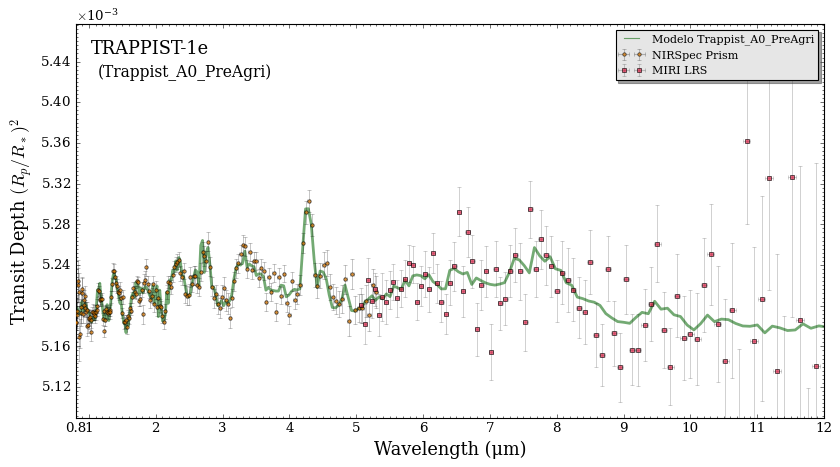

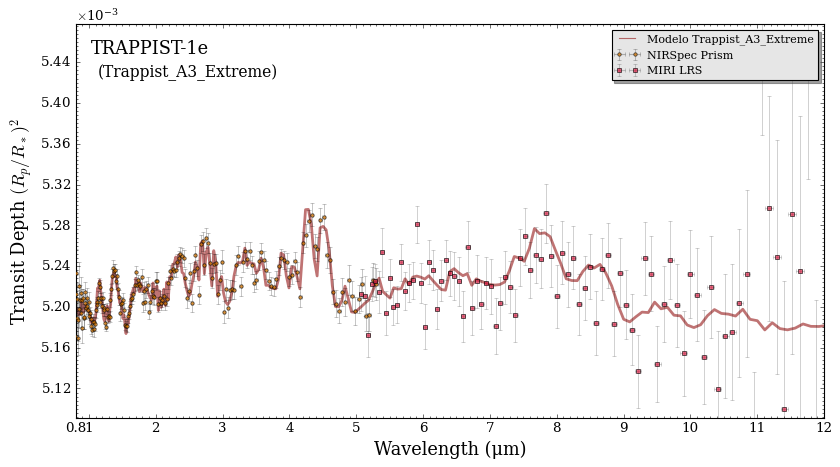

In [21]:
# ============================================================
# A0 & A3 (100 Transits)
# ============================================================
# Modificamos la variable global N_trans a 100 tránsitos
N_trans = [100, 100]

data_A0_new_100, fig_A0_100 = make_and_plot_synthetic_model(
    model_label="Trappist_A0_PreAgri",
    spectrum_model=spectrum_A0,
    model_colour="darkgreen"
)

data_A3_new_100, fig_A3_100 = make_and_plot_synthetic_model(
    model_label="Trappist_A3_Extreme",
    spectrum_model=spectrum_A3,
    model_colour="darkred"
)

In [1]:
from POSEIDON.utility import read_retrieved_spectrum, plot_collection
from POSEIDON.visuals import plot_spectra_retrieved
from POSEIDON.corner import generate_cornerplot

from trappist1e_retrieval_common import (
    PLANET_NAME,
    INSTRUMENTS,
    create_system,
    create_grids,
    make_retrieval_model,
    load_synthetic_data,
)

/home/dasan/anaconda3/envs/POSEIDON/lib/python3.10/site-packages/pysynphot/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [64]:
scenario_key = "A3"
n_transits = 100

star, planet = create_system()
_, wl, _, _ = create_grids()
model = make_retrieval_model(scenario_key, n_transits)
data_new, datasets = load_synthetic_data(wl, scenario_key, n_transits)

planet_name = PLANET_NAME
model_name = model["model_name"]

print(planet_name)
print(model_name)
print(datasets)
print(model["param_names"])

TRAPPIST-1e
TRAPPIST1e_A3_retrieval_isotherm_isochem_100transits
['TRAPPIST-1e_SYNTHETIC_JWST_NIRSpec_PRISM_Trappist_A3_Extreme_N_trans_100.dat', 'TRAPPIST-1e_SYNTHETIC_JWST_MIRI_LRS_Trappist_A3_Extreme_N_trans_100.dat']
['R_p_ref' 'T' 'log_H2O' 'log_CO2' 'log_CH4' 'log_O2' 'log_O3' 'log_N2O'
 'log_NH3']


In [65]:
wl_ret, spec_low2, spec_low1, spec_median, spec_high1, spec_high2 = (
    read_retrieved_spectrum(planet_name, model_name)
)

In [66]:
spectra_median = plot_collection(spec_median, wl_ret, collection=[])
spectra_low1 = plot_collection(spec_low1, wl_ret, collection=[])
spectra_low2 = plot_collection(spec_low2, wl_ret, collection=[])
spectra_high1 = plot_collection(spec_high1, wl_ret, collection=[])
spectra_high2 = plot_collection(spec_high2, wl_ret, collection=[])

In [67]:
mask_plot = (wl_ret >= 0.8) & (wl_ret <= 12.0)

smin = float(spec_median[mask_plot].min())
smax = float(spec_median[mask_plot].max())
span = smax - smin

if span < 2e-5:
    span = 2e-5

pad = 0.35 * span
y_min = smin - pad
y_max = smax + pad

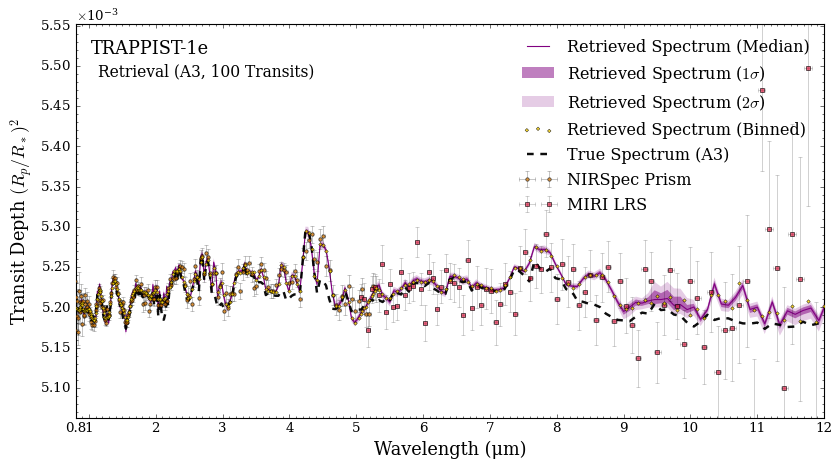

In [68]:
# spectrum_A3 = compute_spectrum(...)
wl_binned_true, spectrum_true = rebin_poseidon(wl, spectrum_A0, R_bin=100)

fig_spec = plot_spectra_retrieved(
    spectra_median,
    spectra_low2,
    spectra_low1,
    spectra_high1,
    spectra_high2,
    planet_name,
    data_new,
    R_to_bin=100,

    data_labels=["NIRSpec Prism", "MIRI LRS"],
    data_colour_list=["darkorange", "crimson"],

    data_alpha_list=[0.65, 0.65],
    data_eline_alpha_list=[0.25, 0.20],
    data_eline_width_list=[0.8, 0.8],

    y_min=y_min,
    y_max=y_max,
    wl_min=0.8,
    wl_max=12.0,
    figure_shape="wide",
    wl_axis="linear",
    plt_label=f"Retrieval ({scenario_key}, {n_transits} Transits)",
)

# Obtenemos el eje ('axis') de la figura generada para poder pintar encima
ax = fig_spec.axes[0]

ax.plot(
    wl_binned_true,
    spectrum_true,
    color="black",
    lw=2.2,
    alpha=0.95,
    ls="--",
    label=f"True Spectrum ({scenario_key})",
    zorder=30,
)

ax.legend(loc="upper right", frameon=False)


TRAPPIST-1e
TRAPPIST1e_A3_retrieval_isotherm_isochem_100transits
['TRAPPIST-1e_SYNTHETIC_JWST_NIRSpec_PRISM_Trappist_A3_Extreme_N_trans_100.dat', 'TRAPPIST-1e_SYNTHETIC_JWST_MIRI_LRS_Trappist_A3_Extreme_N_trans_100.dat']
['R_p_ref' 'T' 'log_H2O' 'log_CO2' 'log_CH4' 'log_O2' 'log_O3' 'log_N2O'
 'log_NH3']


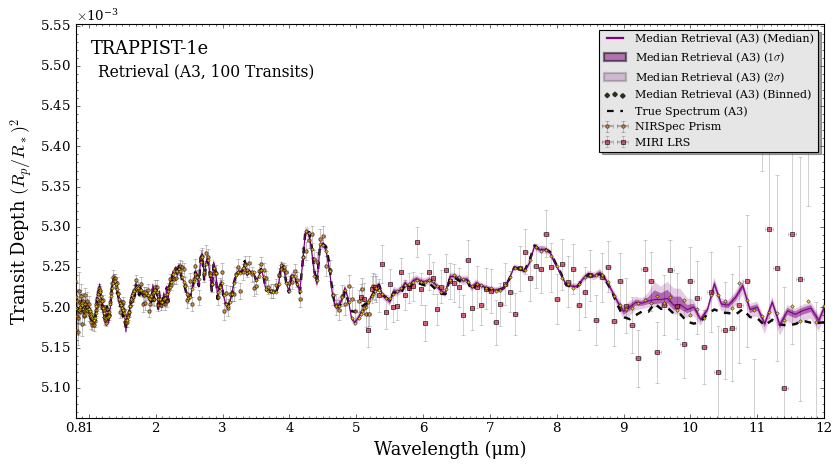

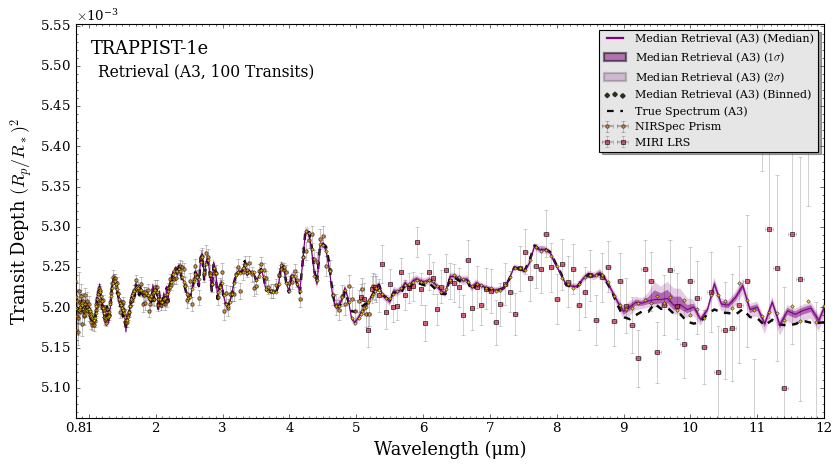

<Figure size 853.36x480 with 0 Axes>

In [63]:
from POSEIDON.utility import read_retrieved_spectrum, plot_collection
from POSEIDON.visuals import plot_spectra_retrieved, plot_spectra
from POSEIDON.corner import generate_cornerplot

from trappist1e_retrieval_common import (
    PLANET_NAME,
    INSTRUMENTS,
    create_system,
    create_grids,
    make_retrieval_model,
    load_synthetic_data,
)

scenario_key = "A3"
n_transits = 100

# ------------------------------------------------------------
# System, grids and retrieval model
# ------------------------------------------------------------
star, planet = create_system()
_, wl, _, _ = create_grids()
model = make_retrieval_model(scenario_key, n_transits)
data_new, datasets = load_synthetic_data(wl, scenario_key, n_transits)

planet_name = PLANET_NAME
model_name = model["model_name"]

print(planet_name)
print(model_name)
print(datasets)
print(model["param_names"])

# ------------------------------------------------------------
# Read retrieved spectrum
# ------------------------------------------------------------
wl_ret, spec_low2, spec_low1, spec_median, spec_high1, spec_high2 = (
    read_retrieved_spectrum(planet_name, model_name)
)

spectra_median = plot_collection(spec_median, wl_ret, collection=[])
spectra_low1   = plot_collection(spec_low1,   wl_ret, collection=[])
spectra_low2   = plot_collection(spec_low2,   wl_ret, collection=[])
spectra_high1  = plot_collection(spec_high1,  wl_ret, collection=[])
spectra_high2  = plot_collection(spec_high2,  wl_ret, collection=[])

# ------------------------------------------------------------
# Plot limits
# ------------------------------------------------------------
mask_plot = (wl_ret >= 0.8) & (wl_ret <= 12.0)

smin = float(spec_median[mask_plot].min())
smax = float(spec_median[mask_plot].max())
span = smax - smin

if span < 2e-5:
    span = 2e-5

pad = 0.35 * span
y_min = smin - pad
y_max = smax + pad

# ------------------------------------------------------------
# 1) Plot retrieval with POSEIDON
#    Without legend yet
# ------------------------------------------------------------
fig_spec = plot_spectra_retrieved(
    spectra_median,
    spectra_low2,
    spectra_low1,
    spectra_high1,
    spectra_high2,
    planet_name,
    data_new,
    R_to_bin=100,

    spectra_labels=[f"Median Retrieval ({scenario_key})"],

    data_labels=["NIRSpec Prism", "MIRI LRS"],
    data_colour_list=["darkorange", "crimson"],

    data_alpha_list=[0.65, 0.65],
    data_eline_alpha_list=[0.25, 0.20],
    data_eline_width_list=[0.8, 0.8],

    y_min=y_min,
    y_max=y_max,
    wl_min=0.8,
    wl_max=12.0,
    figure_shape="wide",
    wl_axis="linear",
    plt_label=f"Retrieval ({scenario_key}, {n_transits} Transits)",

    show_legend=False,
    save_fig=False,
)

# ------------------------------------------------------------
# 2) Build true spectrum as a POSEIDON collection
#    and superimpose it with plot_spectra
# ------------------------------------------------------------
true_spectrum_map = {
    "A0": spectrum_A0,
    "A3": spectrum_A3,
}

spectra_true = plot_collection(
    true_spectrum_map[scenario_key],
    wl,
    collection=[],
)

ax_main = fig_spec.axes[0]

_ = plot_spectra(
    spectra_true,
    planet,
    ax=ax_main,

    R_to_bin=100,
    plot_full_res=False,
    show_data=False,

    spectra_labels=[f"True Spectrum ({scenario_key})"],
    colour_list=["black"],
    line_style_list=["--"],
    line_width_list=[2.2],
    line_alpha_list=[0.95],

    y_min=y_min,
    y_max=y_max,
    wl_min=0.8,
    wl_max=12.0,
    figure_shape="wide",
    wl_axis="linear",

    show_planet_name=False,
    plt_label=None,
    show_legend=True,
    legend_location="upper right",
    save_fig=False,
)

fig_spec

Generating corner plot ...


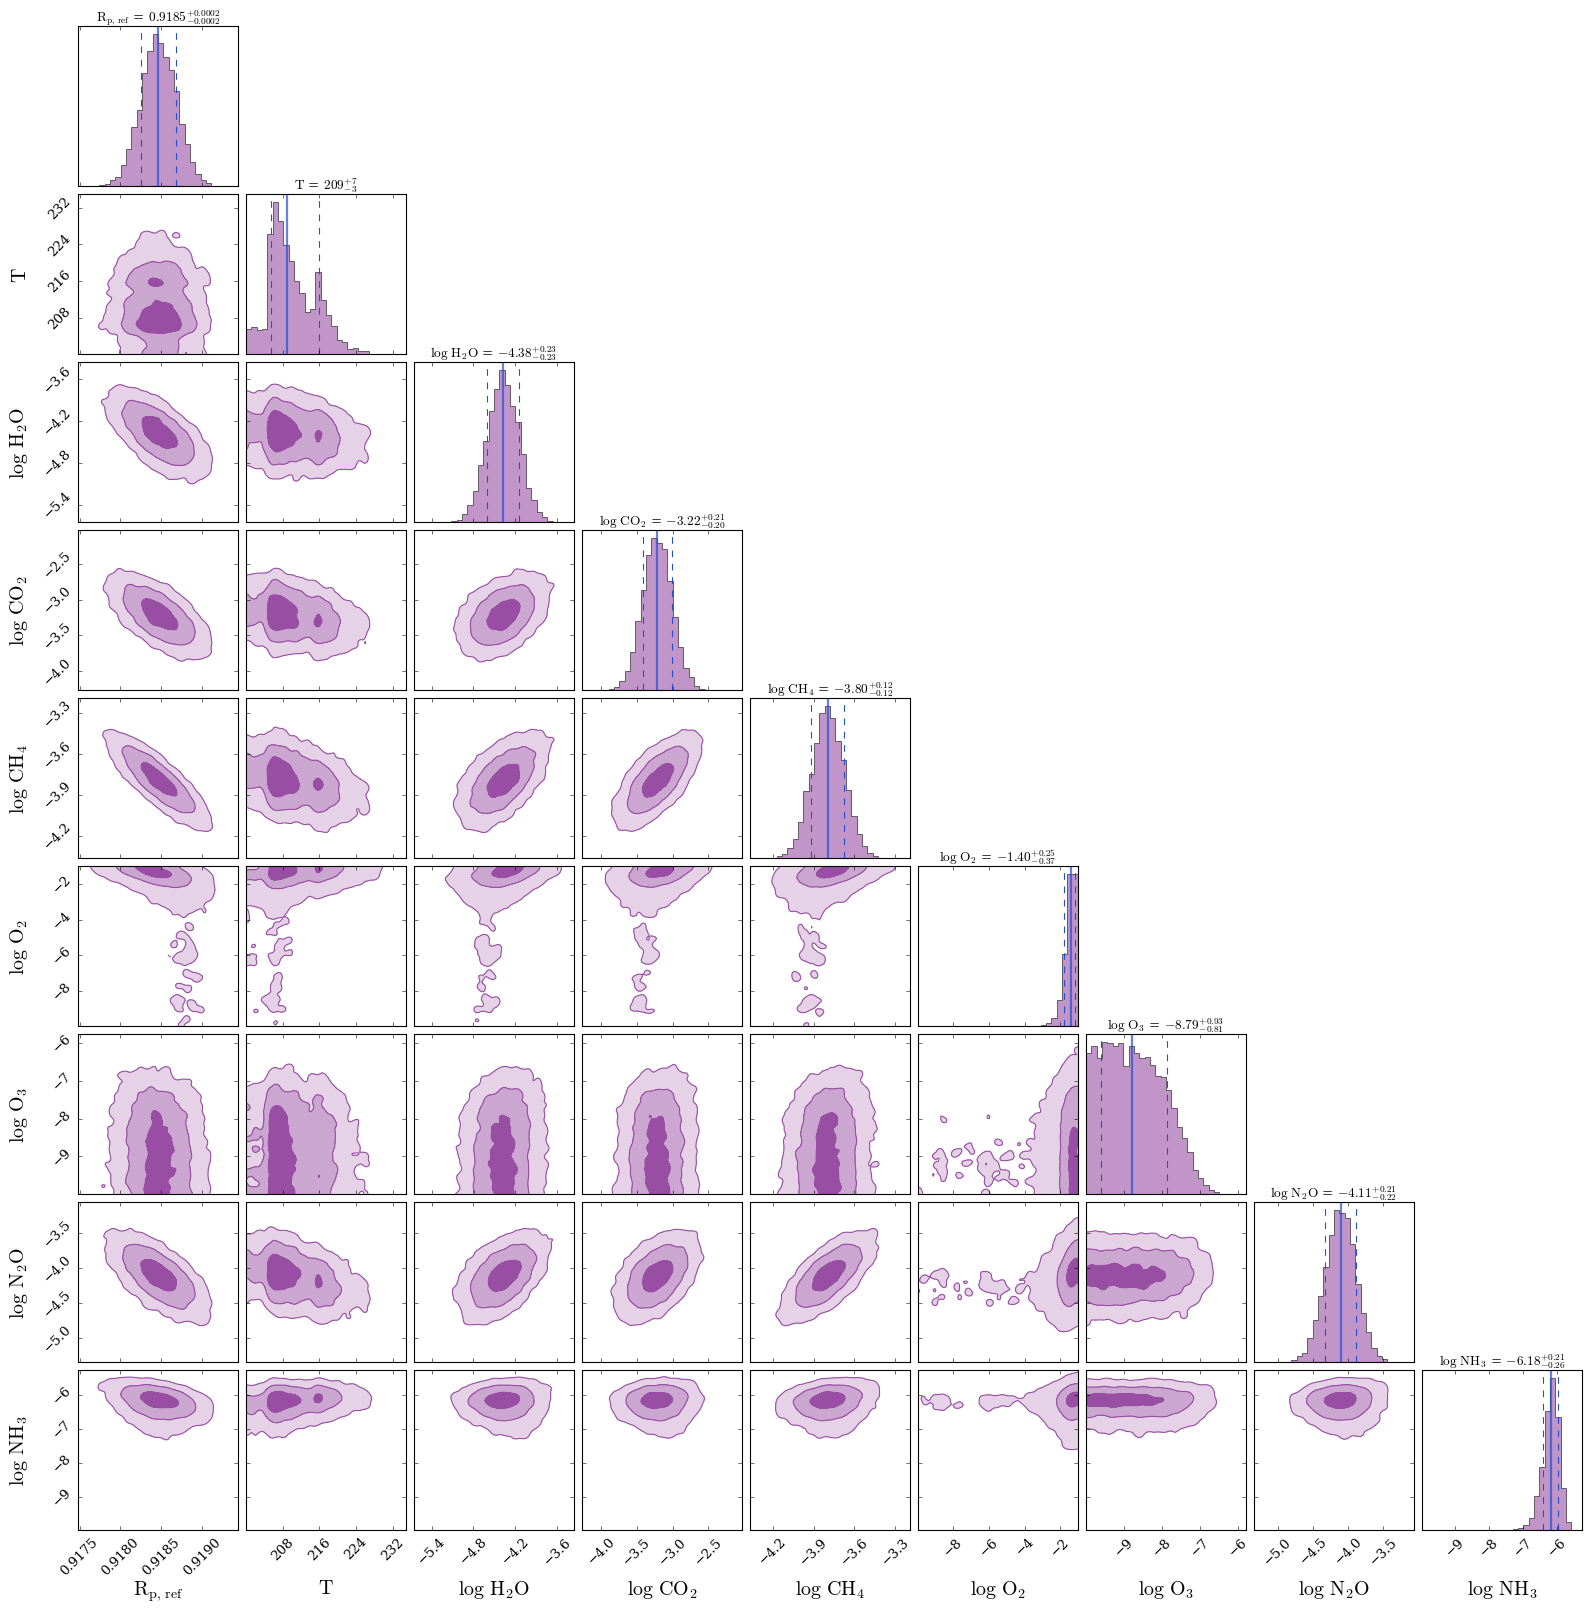

In [69]:
fig_corner = generate_cornerplot(planet, model)